In [6]:
import os, joblib
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

MODEL_PATH = "../saved_model/ae_model.keras"
SCALER_PATH = "../saved_model/scaler.joblib"
META_PATH   = "../saved_model/detector_meta.joblib"

X_PATH = "../data/processed/X_all.npy"
C_PATH = "../data/processed/C_all.npy"

print("Paths set ✅")

Paths set ✅


In [7]:
@keras.utils.register_keras_serializable(package="Custom")
class FiLM(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.modulation = layers.Dense(2 * units)

    def call(self, inputs):
        x, context = inputs
        gamma_beta = self.modulation(context)
        gamma, beta = tf.split(gamma_beta, 2, axis=-1)
        gamma = tf.expand_dims(gamma, axis=1)  # (B, 1, units)
        beta  = tf.expand_dims(beta, axis=1)
        return x * (1.0 + gamma) + beta

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg

print("FiLM defined ✅")

FiLM defined ✅


In [8]:
# Load model with custom_objects (fixes FiLM error)
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"FiLM": FiLM},
    compile=False
)

scaler = joblib.load(SCALER_PATH)
detector_meta = joblib.load(META_PATH)

print("Loaded ✅")
print("Model:", model.name)
print("Detector meta:", detector_meta)

/home/udara/Desktop/Research_model/project/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'fi_lm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/udara/Desktop/Research_model/project/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'fi_lm_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Loaded ✅
Model: functional
Detector meta: {'window_size': 24, 'topk': 50, 'threshold': 60.53527069091797, 'q': 0.995}


In [9]:
X = np.load(X_PATH)
C = np.load(C_PATH)

print("Raw loaded:")
print("X:", X.shape, "C:", C.shape)

# subset (adjust as you want)
N_CLEAN = min(5000, len(X))
X_clean = X[:N_CLEAN]
C_clean = C[:N_CLEAN]

def apply_scaler(sc, X):
    N, T, F = X.shape
    return sc.transform(X.reshape(N*T, F)).reshape(N, T, F).astype(np.float32)

X_clean = apply_scaler(scaler, X_clean)

print("Scaled clean subset ✅")
print("X_clean:", X_clean.shape, "C_clean:", C_clean.shape)

Raw loaded:
X: (53414, 24, 8) C: (53414, 5)
Scaled clean subset ✅
X_clean: (5000, 24, 8) C_clean: (5000, 5)


In [10]:
def topk_score(x_true: np.ndarray, x_pred: np.ndarray, k: int) -> np.ndarray:
    err = (x_true - x_pred) ** 2
    flat = err.reshape(len(err), -1)
    k = min(k, flat.shape[1])
    part = np.partition(flat, -k, axis=1)[:, -k:]
    return np.mean(part, axis=1)

In [11]:
def inject_anomalies(
    x, anomaly_ratio=0.08, seed=42,
    spike_mag=6.0, noise_std=0.8,
    seg_len=12, n_affect=2
):
    rng = np.random.default_rng(seed)
    x_anom = x.copy()
    n, T, F = x_anom.shape

    k = int(n * anomaly_ratio)
    idx = rng.choice(n, k, replace=False)

    y = np.zeros(n, dtype=np.int32)
    y[idx] = 1

    for i in idx:
        seg = min(seg_len, T)
        t0 = int(rng.integers(0, max(1, T - seg + 1)))
        feats = rng.choice(F, size=min(n_affect, F), replace=False)
        t_idx = np.arange(t0, t0 + seg)

        mode = rng.choice(["spike","drop","noise"])
        if mode == "spike":
            x_anom[i][np.ix_(t_idx, feats)] += spike_mag
        elif mode == "drop":
            x_anom[i][np.ix_(t_idx, feats)] -= spike_mag
        else:
            x_anom[i][np.ix_(t_idx, feats)] += rng.normal(
                0, noise_std, size=(len(t_idx), len(feats))
            )

    return x_anom, y

In [12]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

TOPK = int(detector_meta.get("topk", 50))
THRESH = float(detector_meta.get("threshold", 0.0))

X_test, y_true = inject_anomalies(
    X_clean,
    anomaly_ratio=0.08,
    seed=42
)

# predict
X_pred = model.predict([X_test, C_clean], verbose=0)

scores = topk_score(X_test, X_pred, TOPK)
y_hat = (scores >= THRESH).astype(int)

p, r, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
cm = confusion_matrix(y_true, y_hat)

pr_auc = average_precision_score(y_true, scores)
roc_auc = roc_auc_score(y_true, scores)

print("✅ RESULTS")
print("Precision:", float(p))
print("Recall   :", float(r))
print("F1       :", float(f1))
print("PR-AUC   :", float(pr_auc))
print("ROC-AUC  :", float(roc_auc))
print("Confusion Matrix:\n", cm)

✅ RESULTS
Precision: 0.5092592592592593
Recall   : 0.1375
F1       : 0.21653543307086615
PR-AUC   : 0.47226128378851845
ROC-AUC  : 0.8487266304347826
Confusion Matrix:
 [[4547   53]
 [ 345   55]]


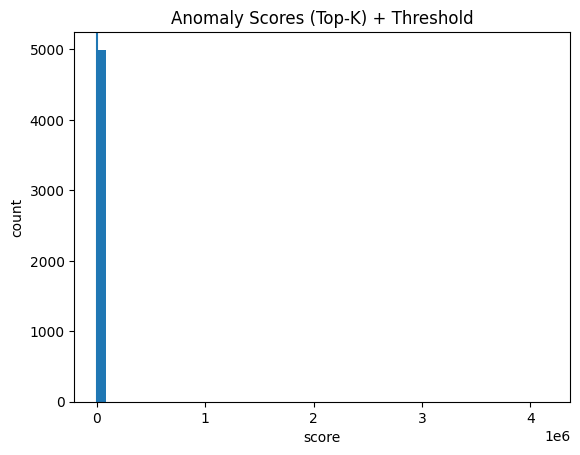

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(scores, bins=50)
plt.axvline(THRESH)
plt.title("Anomaly Scores (Top-K) + Threshold")
plt.xlabel("score")
plt.ylabel("count")
plt.show()